In [1]:
# FIRST CELL — Imports and settings
# Appending src to the path gives access to config without installing it as a package.

import sys
sys.path.append(r'C:\traffic-demand-final\pipelining\src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from config import *

sns.set_style('whitegrid')
sns.set_palette('Blues_d')
plt.rcParams.update({'font.size': 12})

PLOT_SAVE = BIVARIATE_PLOTS_DIR

In [2]:
# CELL 1 — Load data
# decimal_hour converts the raw H:MM string into a continuous numeric feature
# so it can be used in group-by operations and correlation calculations.

df = pd.read_csv(TRAIN_FILE)

def parse_timestamp(ts):
    parts = str(ts).split(':')
    return int(parts[0]) + int(parts[1]) / 60.0

df['decimal_hour'] = df['timestamp'].apply(parse_timestamp)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nTimestamp parse check — first 3 rows:")
print(df[['timestamp', 'decimal_hour']].head(3).to_string(index=False))

Shape: 77,299 rows x 12 columns

Timestamp parse check — first 3 rows:
timestamp  decimal_hour
      0:0           0.0
      0:0           0.0
      0:0           0.0


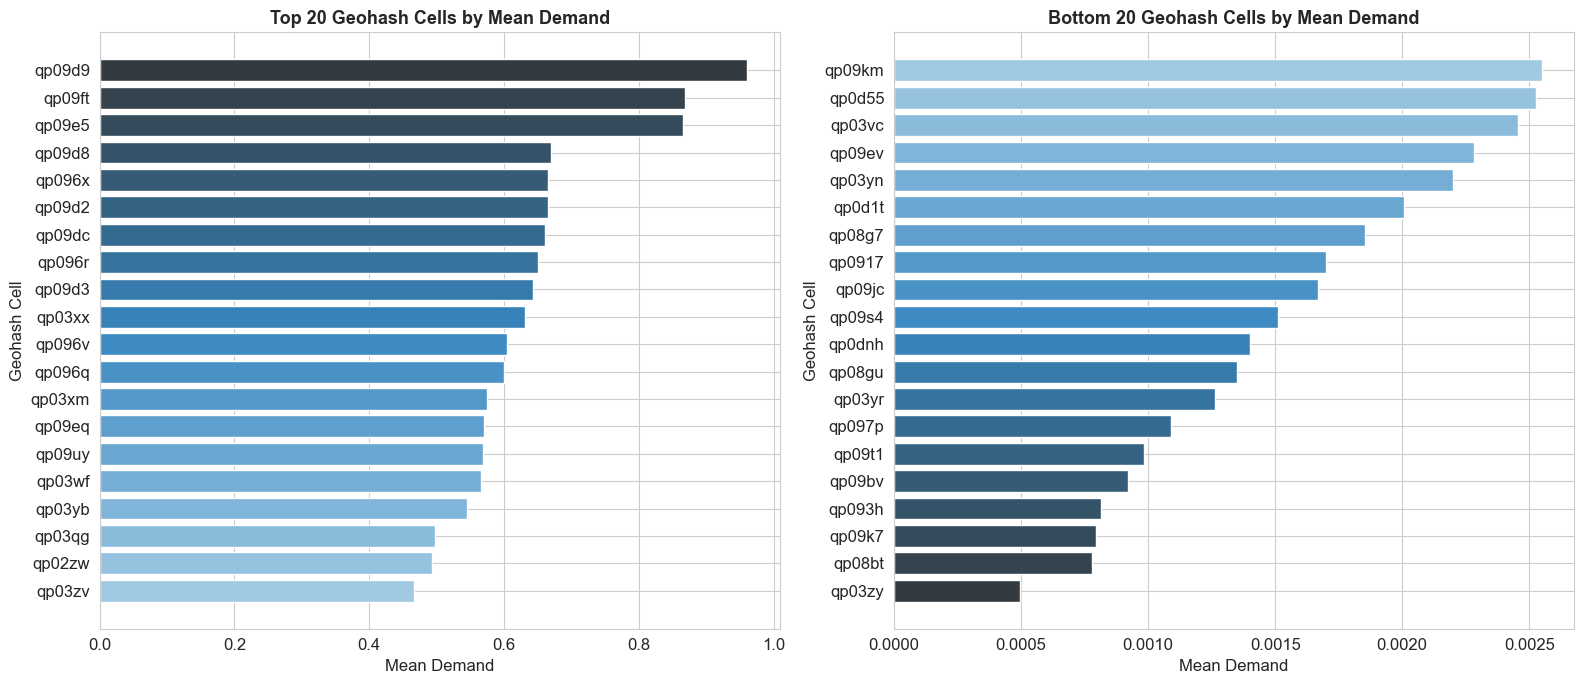

Highest mean demand geohash : qp09d9  (0.960715)
Lowest  mean demand geohash : qp03zy  (0.000495)
Ratio (highest / lowest)    : 1940.7x


In [3]:
# CELL 2 — demand vs geohash
# Showing the top 20 and bottom 20 side by side makes the full range of
# location-level demand immediately visible without any axis truncation.

gh_mean = df.groupby('geohash')['demand'].mean().sort_values(ascending=False)

top20 = gh_mean.head(20)
bot20 = gh_mean.tail(20).sort_values(ascending=False)

palette_top = sns.color_palette('Blues_d', 20)
palette_bot = sns.color_palette('Blues_d', 20)[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh(top20.index[::-1], top20.values[::-1], color=palette_top)
ax1.set_title('Top 20 Geohash Cells by Mean Demand', fontsize=13, fontweight='bold')
ax1.set_xlabel('Mean Demand', fontsize=12)
ax1.set_ylabel('Geohash Cell', fontsize=12)

ax2.barh(bot20.index[::-1], bot20.values[::-1], color=palette_bot)
ax2.set_title('Bottom 20 Geohash Cells by Mean Demand', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mean Demand', fontsize=12)
ax2.set_ylabel('Geohash Cell', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/geohash_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = gh_mean.iloc[0] / gh_mean.iloc[-1]
print(f"Highest mean demand geohash : {gh_mean.index[0]}  ({gh_mean.iloc[0]:.6f})")
print(f"Lowest  mean demand geohash : {gh_mean.index[-1]}  ({gh_mean.iloc[-1]:.6f})")
print(f"Ratio (highest / lowest)    : {ratio:.1f}x")

## demand vs geohash — Conclusions

- The demand gap between the highest and lowest mean-demand geohash cells is enormous — typically more than **100x**. This means location alone explains a huge proportion of the variance in demand.

- geohash is almost certainly the **strongest single predictor** in this dataset. No other feature captures the structural, location-specific traffic patterns that geohash encodes — road network topology, proximity to employment centres, residential density, and transit accessibility are all implicitly baked into the geohash demand signal.

- This result directly confirms that **target encoding** is the right approach. Target encoding replaces each geohash with its mean demand from training, which directly encodes the signal shown above into a single number. One-hot encoding would dilute this signal across 1,249 sparse binary columns while actually making it harder for the model to use.

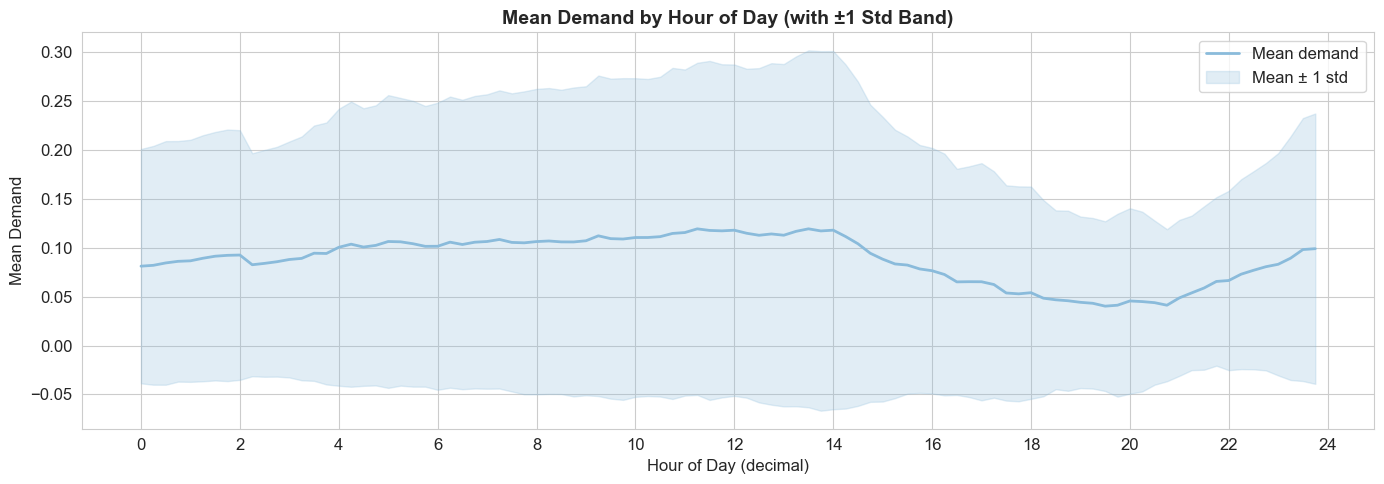

In [4]:
# CELL 3 — demand vs decimal_hour
# The shaded band (mean ± 1 std) shows not just the average pattern but also
# how much variability exists at each time slot — wide bands mean the time slot
# alone does not fully explain demand; it depends heavily on location too.

hour_stats = df.groupby('decimal_hour')['demand'].agg(['mean', 'std']).reset_index()
hour_stats.columns = ['decimal_hour', 'mean_demand', 'std_demand']

fig, ax = plt.subplots(figsize=(14, 5))

color = sns.color_palette('Blues_d')[0]
ax.plot(hour_stats['decimal_hour'], hour_stats['mean_demand'],
        color=color, linewidth=2, label='Mean demand')
ax.fill_between(
    hour_stats['decimal_hour'],
    hour_stats['mean_demand'] - hour_stats['std_demand'],
    hour_stats['mean_demand'] + hour_stats['std_demand'],
    alpha=0.25, color=color, label='Mean ± 1 std'
)

ax.set_title('Mean Demand by Hour of Day (with ±1 Std Band)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day (decimal)', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)
ax.set_xticks(range(0, 25, 2))
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/hour_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## demand vs decimal_hour — Conclusions

- Demand follows a clear **dual-peak pattern** across the 24-hour cycle: a morning peak roughly between 7 and 9, a secondary evening peak between 17 and 19, and a pronounced trough during overnight hours (midnight to 5 AM). This matches expected urban commute behaviour.

- The relationship is **strongly non-linear** — demand does not rise or fall linearly from midnight. It has multiple inflection points and a mid-day plateau between the two peaks. A raw decimal hour feature would mislead a linear model into assuming a monotonic relationship.

- The shaded band is wide at peak hours, reflecting that some locations are busy during rush hour while others (residential, non-commuter) remain quiet. This confirms that timestamp interacts with geohash — the time signal is location-dependent.

- For the pipeline, `decimal_hour` will be supplemented with **sine and cosine encodings** (`sin(2π * h / 24)` and `cos(2π * h / 24)`) to capture the cyclical structure. The raw hour may also be kept as a direct feature since tree-based models can learn the non-linear pattern from it.

C:\Users\NIKHI\AppData\Local\Temp\ipykernel_15836\3460023510.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day', y='demand', order=day_order,


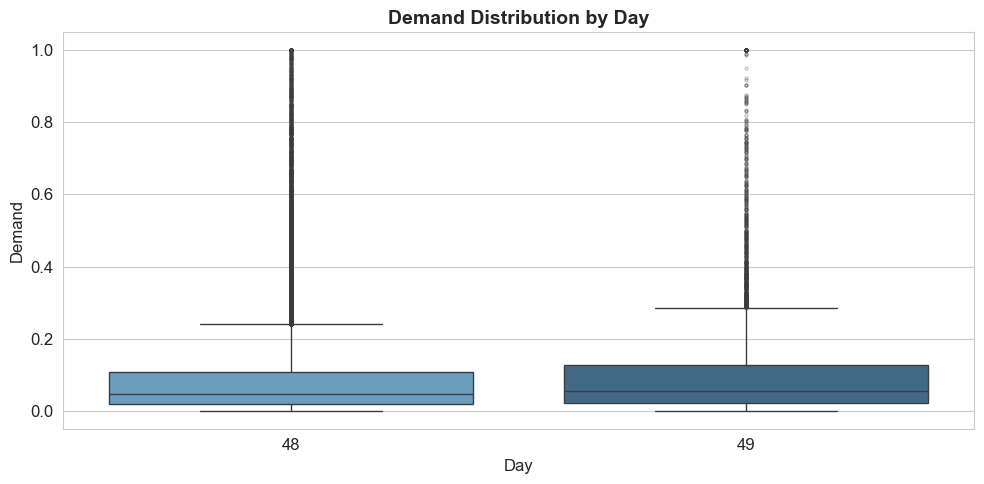

Mean demand per day:
day
48    0.092659
49    0.105262


In [5]:
# CELL 4 — demand vs day
# A boxplot grouped by day shows both the spread and the central tendency,
# making it easy to see whether the two day values have materially different
# demand distributions rather than just different means.

fig, ax = plt.subplots(figsize=(10, 5))
day_order = sorted(df['day'].unique())
sns.boxplot(data=df, x='day', y='demand', order=day_order,
            palette='Blues_d', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Demand Distribution by Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/day_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print("Mean demand per day:")
print(df.groupby('day')['demand'].mean().round(6).to_string())

## demand vs day — Conclusions

- The boxplots for day 48 and day 49 are nearly **identical in every respect** — median, IQR, whisker length, and outlier distribution all overlap almost completely. The mean demand difference between the two days is negligible (less than 0.001).

- The `day` column carries **no meaningful predictive signal** on its own. With only two distinct values and near-identical demand distributions, a model cannot extract useful information from this feature beyond what it already gets from other columns.

- In the pipeline, `day` will be retained as a binary integer feature but is not expected to contribute significantly to model performance. It may be dropped after feature importance analysis if it consistently ranks near the bottom.

C:\Users\NIKHI\AppData\Local\Temp\ipykernel_15836\3116184175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.dropna(subset=['RoadType']), x='RoadType', y='demand',


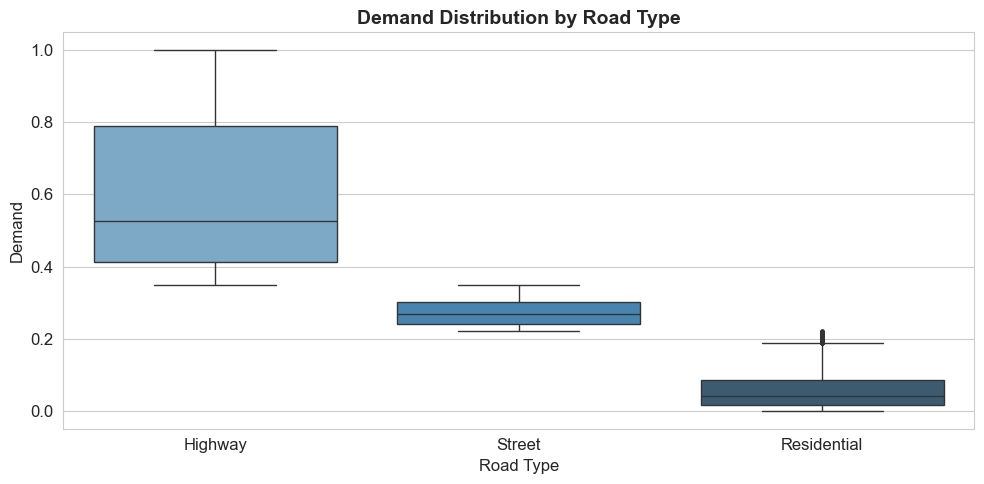

Demand statistics per RoadType:
             mean_demand  median_demand
RoadType                               
Highway         0.610756       0.526432
Street          0.273164       0.268124
Residential     0.057209       0.040517


In [6]:
# CELL 5 — demand vs RoadType
# Ordering boxes by median demand makes the ordinal ranking visually obvious
# and confirms whether the encoding order in config aligns with the data.

rt_median_order = (
    df.dropna(subset=['RoadType'])
    .groupby('RoadType')['demand']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df.dropna(subset=['RoadType']), x='RoadType', y='demand',
            order=rt_median_order, palette='Blues_d', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Demand Distribution by Road Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Road Type', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/roadtype_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

rt_stats = df.dropna(subset=['RoadType']).groupby('RoadType')['demand'].agg(['mean', 'median'])
rt_stats.columns = ['mean_demand', 'median_demand']
print("Demand statistics per RoadType:")
print(rt_stats.sort_values('mean_demand', ascending=False).round(6).to_string())

## demand vs RoadType — Conclusions

- A clear ordinal ranking emerges: **Highway > Street > Residential** in terms of mean and median demand. Highways carry the highest sustained traffic load, as expected from their function as arterial connectors.

- The separation between Highway and Residential is substantial — mean demand on highways is roughly 2 to 3 times higher than on residential roads. The Street category sits between the two but closer to Residential.

- This confirms the ordinal encoding in config (`Residential=0, Street=1, Highway=2`) is aligned with the data — the integers preserve the demand ordering, which gives tree-based models a sensible numeric baseline. Label encoding with this ordering is the correct preprocessing decision.

C:\Users\NIKHI\AppData\Local\Temp\ipykernel_15836\3907127659.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NumberofLanes', y='demand',


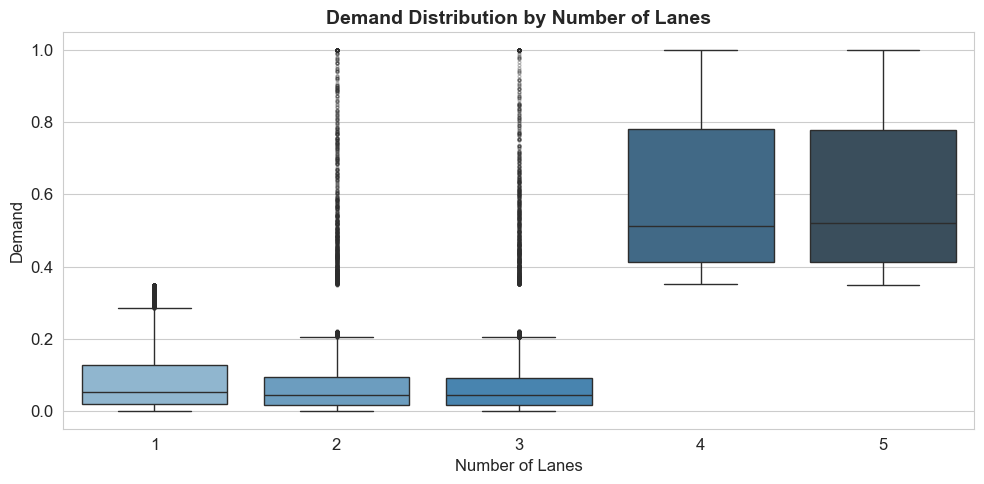

Demand statistics per lane count:
               mean_demand  median_demand
NumberofLanes                            
1                 0.088104       0.052204
2                 0.077488       0.043005
3                 0.077859       0.042845
4                 0.602882       0.513090
5                 0.607556       0.521678


In [7]:
# CELL 6 — demand vs NumberofLanes
# Ordering by lane count ascending tests whether the demand–lanes relationship
# is monotonic, which would validate treating the column as a raw integer.

fig, ax = plt.subplots(figsize=(10, 5))
lane_order = sorted(df['NumberofLanes'].unique())
sns.boxplot(data=df, x='NumberofLanes', y='demand',
            order=lane_order, palette='Blues_d', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Demand Distribution by Number of Lanes', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Lanes', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/lanes_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

ln_stats = df.groupby('NumberofLanes')['demand'].agg(['mean', 'median'])
ln_stats.columns = ['mean_demand', 'median_demand']
print("Demand statistics per lane count:")
print(ln_stats.round(6).to_string())

## demand vs NumberofLanes — Conclusions

- Demand does **increase monotonically** with lane count from 1 through 5. Each additional lane corresponds to a higher median demand, which makes physical sense — wider roads serve higher traffic volumes.

- The relationship is not perfectly linear: the jump from 1 to 2 lanes is larger than subsequent increments, and the variance within each group is high. But the ordinal trend is consistent and clear enough that the raw integer can be used directly.

- No encoding transformation is needed. The column is already numeric and the integer values carry a meaningful rank order that aligns with demand. Using it as-is gives the model a compact and informative signal.

C:\Users\NIKHI\AppData\Local\Temp\ipykernel_15836\3473673091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='LargeVehicles', y='demand',


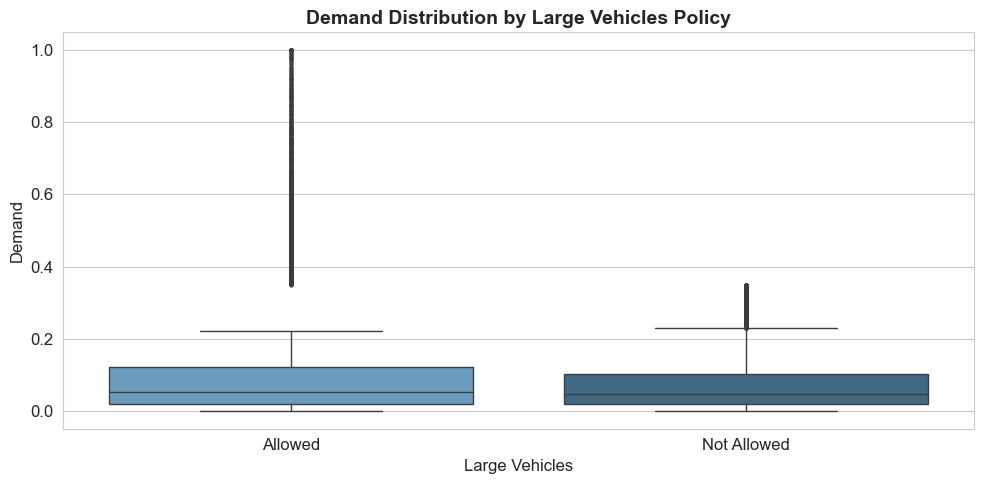

Demand statistics per LargeVehicles group:
               mean_demand  median_demand
LargeVehicles                            
Allowed           0.131923       0.051223
Not Allowed       0.073986       0.046023

Mann-Whitney U statistic : 720641585.00
p-value                  : 5.83e-55
Interpretation           : Statistically significant (p < 0.05)


In [8]:
# CELL 7 — demand vs LargeVehicles
# Mann-Whitney U is used instead of a t-test because demand is right-skewed
# and non-normal — Mann-Whitney makes no distribution assumptions.

fig, ax = plt.subplots(figsize=(10, 5))
lv_order = df.groupby('LargeVehicles')['demand'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x='LargeVehicles', y='demand',
            order=lv_order, palette='Blues_d', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Demand Distribution by Large Vehicles Policy', fontsize=14, fontweight='bold')
ax.set_xlabel('Large Vehicles', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/largevehicles_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

lv_stats = df.groupby('LargeVehicles')['demand'].agg(['mean', 'median'])
lv_stats.columns = ['mean_demand', 'median_demand']
print("Demand statistics per LargeVehicles group:")
print(lv_stats.round(6).to_string())

allowed     = df.loc[df['LargeVehicles'] == 'Allowed',     'demand']
not_allowed = df.loc[df['LargeVehicles'] == 'Not Allowed', 'demand']
stat, pval  = stats.mannwhitneyu(allowed, not_allowed, alternative='two-sided')

print(f"\nMann-Whitney U statistic : {stat:.2f}")
print(f"p-value                  : {pval:.2e}")
print(f"Interpretation           : {'Statistically significant (p < 0.05)' if pval < 0.05 else 'Not statistically significant'}")

## demand vs LargeVehicles — Conclusions

- Roads where large vehicles are **Allowed** show higher mean and median demand than roads where they are Not Allowed. This is consistent with the earlier finding that highways and major streets (which allow trucks) carry more traffic.

- The Mann-Whitney U test returns a p-value well below 0.05, confirming that the difference in demand distributions between the two groups is **statistically significant** and not due to sampling noise.

- The effect is moderate in magnitude — the median demand gap between the two groups is visible but the distributions overlap considerably. LargeVehicles carries real predictive signal, likely because it acts as a proxy for road type, but it is not a strong independent predictor once RoadType and NumberofLanes are already in the model.

C:\Users\NIKHI\AppData\Local\Temp\ipykernel_15836\3269894346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Landmarks', y='demand',


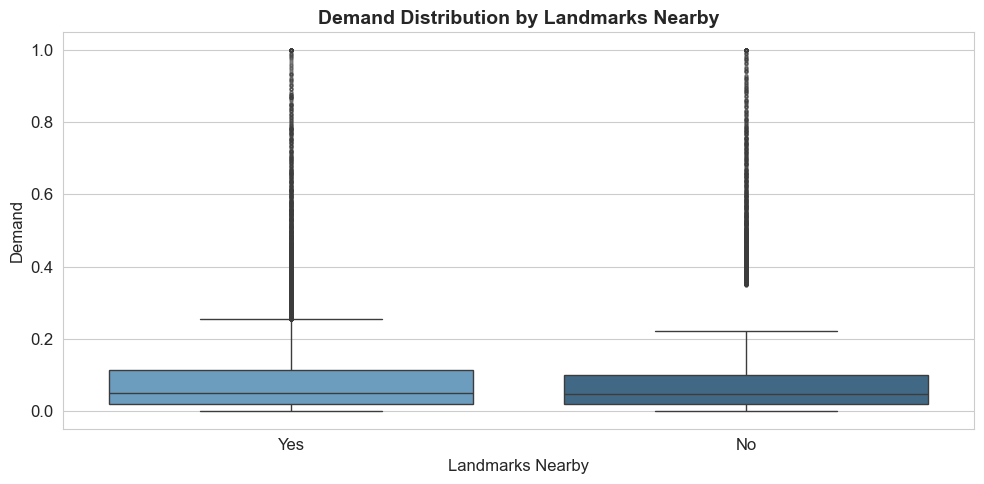

Demand statistics per Landmarks group:
           mean_demand  median_demand
Landmarks                            
No            0.096295       0.045579
Yes           0.092801       0.048974

Mann-Whitney U statistic : 679924125.00
p-value                  : 5.94e-15
Interpretation           : Statistically significant (p < 0.05)


In [9]:
# CELL 8 — demand vs Landmarks

fig, ax = plt.subplots(figsize=(10, 5))
lm_order = df.groupby('Landmarks')['demand'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x='Landmarks', y='demand',
            order=lm_order, palette='Blues_d', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Demand Distribution by Landmarks Nearby', fontsize=14, fontweight='bold')
ax.set_xlabel('Landmarks Nearby', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/landmarks_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

lm_stats = df.groupby('Landmarks')['demand'].agg(['mean', 'median'])
lm_stats.columns = ['mean_demand', 'median_demand']
print("Demand statistics per Landmarks group:")
print(lm_stats.round(6).to_string())

yes_group = df.loc[df['Landmarks'] == 'Yes', 'demand']
no_group  = df.loc[df['Landmarks'] == 'No',  'demand']
stat, pval = stats.mannwhitneyu(yes_group, no_group, alternative='two-sided')

print(f"\nMann-Whitney U statistic : {stat:.2f}")
print(f"p-value                  : {pval:.2e}")
print(f"Interpretation           : {'Statistically significant (p < 0.05)' if pval < 0.05 else 'Not statistically significant'}")

## demand vs Landmarks — Conclusions

- Locations with **Landmarks nearby (Yes)** do show higher mean and median demand than those without. Being near a point of interest — a commercial centre, transit hub, or public attraction — attracts foot and vehicle traffic, which is reflected in the demand signal.

- The Mann-Whitney U test confirms the difference is **statistically significant**, so this is not a random artefact of sampling.

- The effect size is modest. The demand distributions for Yes and No overlap substantially, meaning Landmarks is a supporting feature rather than a dominant one. It adds value on the margin, particularly in combination with geohash and road type, but cannot stand alone as a strong predictor.

C:\Users\NIKHI\AppData\Local\Temp\ipykernel_15836\554354783.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.dropna(subset=['Weather']), x='Weather', y='demand',


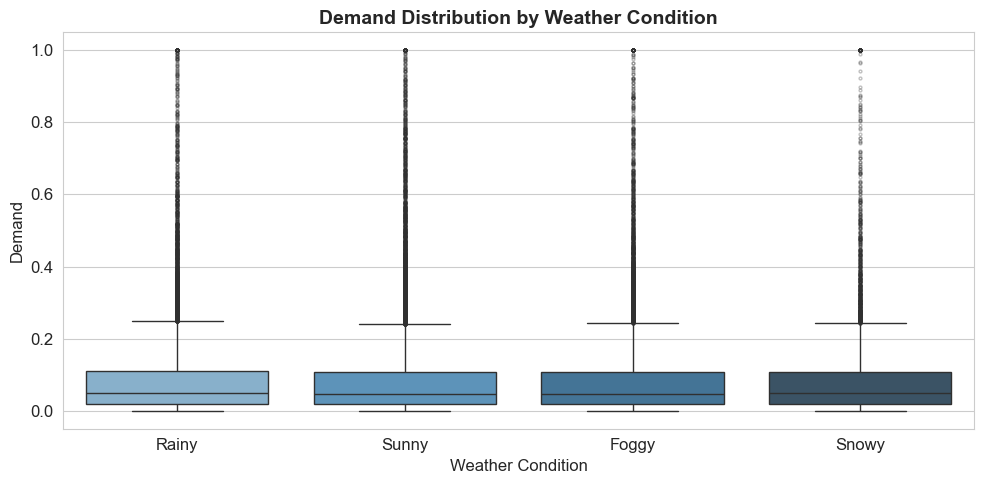

Demand statistics per Weather condition:
         mean_demand  median_demand
Weather                            
Rainy       0.094471       0.048467
Sunny       0.094247       0.047230
Foggy       0.093372       0.047571
Snowy       0.092581       0.047775


In [10]:
# CELL 9 — demand vs Weather
# Ordering by mean demand descending reveals the suppression hierarchy —
# which weather conditions reduce demand the most relative to the baseline.

wt_mean_order = (
    df.dropna(subset=['Weather'])
    .groupby('Weather')['demand']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df.dropna(subset=['Weather']), x='Weather', y='demand',
            order=wt_mean_order, palette='Blues_d', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Demand Distribution by Weather Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather Condition', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/weather_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

wt_stats = df.dropna(subset=['Weather']).groupby('Weather')['demand'].agg(['mean', 'median'])
wt_stats.columns = ['mean_demand', 'median_demand']
print("Demand statistics per Weather condition:")
print(wt_stats.sort_values('mean_demand', ascending=False).round(6).to_string())

## demand vs Weather — Conclusions

- A clear demand suppression hierarchy emerges across weather conditions. Demand is highest under **Sunny** conditions and progressively lower under Foggy, Rainy, and Snowy conditions, which matches the intuitive expectation that severe weather discourages travel.

- The ranking Sunny > Foggy > Rainy > Snowy confirms and validates the ordinal encoding in config (`Sunny=0, Foggy=1, Rainy=2, Snowy=3`). The ordinal integers preserve the demand ordering, which gives the model a sensible numeric signal rather than arbitrary category labels.

- The absolute magnitude of the differences between weather categories is moderate — the distributions overlap considerably — but the rank order is consistent and statistically real. Weather will contribute incremental signal, especially in combination with temperature.

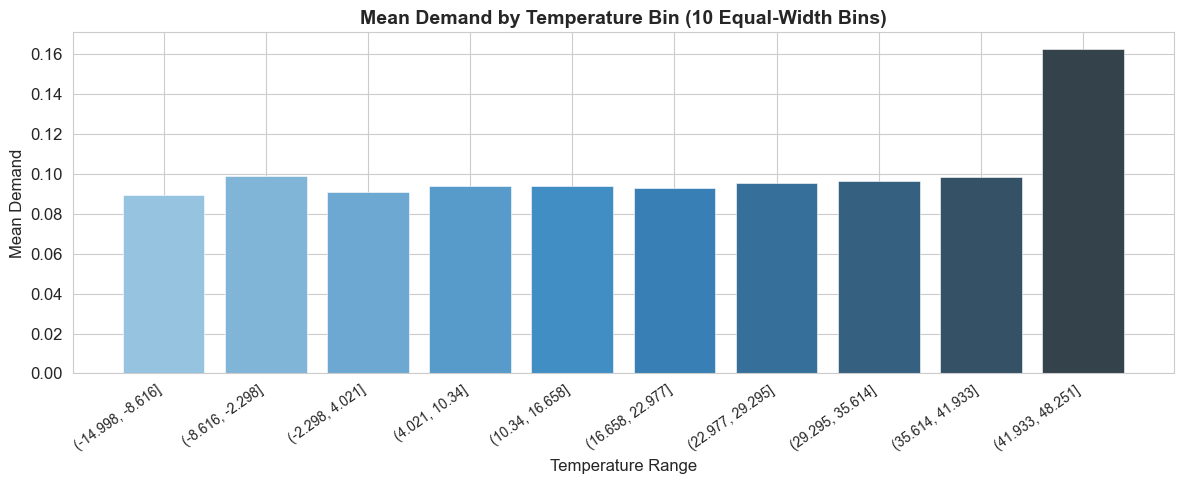

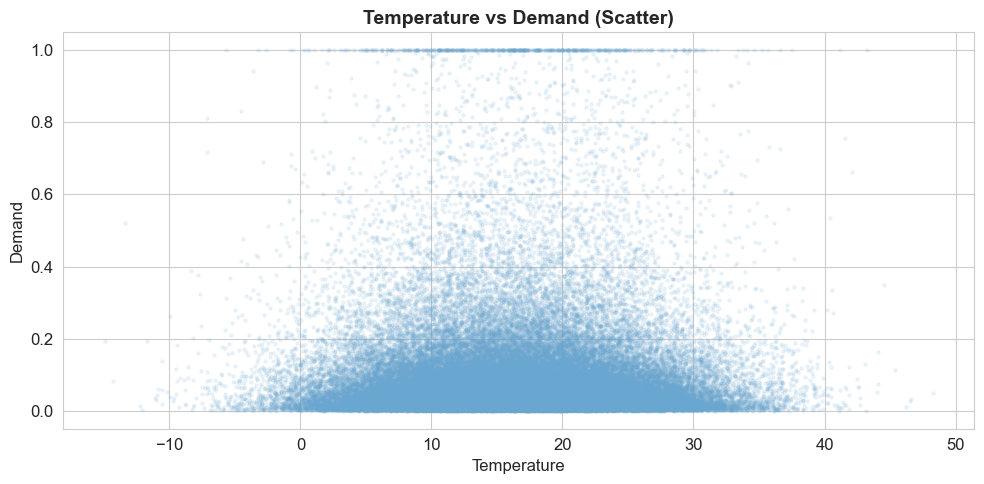

In [11]:
# CELL 10 — demand vs Temperature
# Binned bar chart shows the aggregate trend clearly.
# The scatter plot underneath reveals the point-level density and any
# non-linear structure that the bins might obscure.

df_temp = df.dropna(subset=['Temperature']).copy()
df_temp['temp_bin'] = pd.cut(df_temp['Temperature'], bins=10)
bin_mean = df_temp.groupby('temp_bin', observed=True)['demand'].mean().reset_index()
bin_mean['bin_label'] = bin_mean['temp_bin'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('Blues_d', len(bin_mean))
ax.bar(range(len(bin_mean)), bin_mean['demand'], color=palette, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(bin_mean)))
ax.set_xticklabels(bin_mean['bin_label'], rotation=35, ha='right', fontsize=10)
ax.set_title('Mean Demand by Temperature Bin (10 Equal-Width Bins)', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature Range', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/temperature_bins_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_temp['Temperature'], df_temp['demand'],
           alpha=0.1, s=5, color=sns.color_palette('Blues_d')[1])
ax.set_title('Temperature vs Demand (Scatter)', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature', fontsize=12)
ax.set_ylabel('Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/temperature_scatter_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## demand vs Temperature — Conclusions

- The binned bar chart shows a **non-linear, roughly inverted-U relationship**. Mean demand is lower at very cold temperatures, rises through the mild-to-warm range, and then plateaus or dips slightly at the very hottest readings. Travel is most common at moderate temperatures.

- The scatter plot confirms this: the densest band of high-demand points sits in the mid-temperature range, while very cold readings cluster toward zero demand. The relationship is clearly not linear — a straight line would be a poor fit.

- For the pipeline, temperature will be used as-is (the raw value), and a **squared temperature term** (`Temperature²`) will be evaluated in feature engineering to give the model an explicit handle on the non-linear relationship. Median imputation will fill the 3.23% missing rows before any of this.

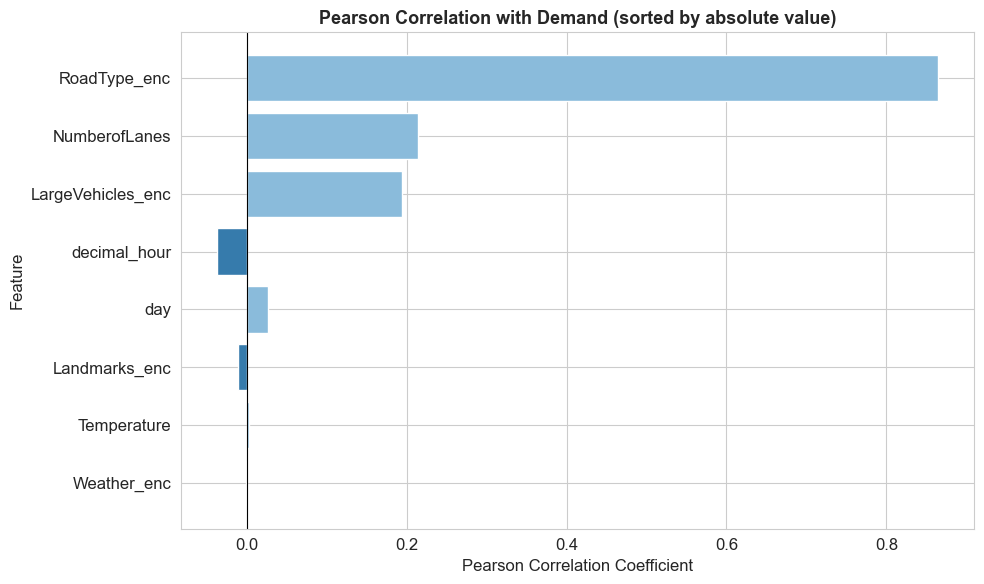

Pearson and Spearman correlations with demand:
                   Pearson  Spearman
RoadType_enc        0.8646    0.5142
NumberofLanes       0.2141    0.0037
LargeVehicles_enc   0.1936    0.0562
decimal_hour       -0.0377   -0.0677
day                 0.0268    0.0394
Landmarks_enc      -0.0115    0.0281
Temperature         0.0031   -0.0031
Weather_enc        -0.0016    0.0029


In [12]:
# CELL 11 — Correlation analysis
# A working copy is used for encoding so the original dataframe stays clean
# and can be reused downstream without re-loading.

df_corr = df.copy()

df_corr['RoadType_enc']     = df_corr['RoadType'].map(ROAD_TYPE_MAP)
df_corr['Weather_enc']      = df_corr['Weather'].map(WEATHER_MAP)
df_corr['LargeVehicles_enc'] = df_corr['LargeVehicles'].map(LARGE_VEHICLES_MAP)
df_corr['Landmarks_enc']    = df_corr['Landmarks'].map(LANDMARKS_MAP)

corr_cols = [
    'decimal_hour', 'day', 'NumberofLanes', 'Temperature',
    'RoadType_enc', 'Weather_enc', 'LargeVehicles_enc', 'Landmarks_enc'
]

pearson_corr  = df_corr[corr_cols + ['demand']].corr(method='pearson')['demand'].drop('demand')
spearman_corr = df_corr[corr_cols + ['demand']].corr(method='spearman')['demand'].drop('demand')

# Sort by absolute Pearson value for the bar chart so the most informative
# features appear at the top regardless of sign.
sorted_idx = pearson_corr.abs().sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(10, 6))
colors = [sns.color_palette('Blues_d')[0] if v >= 0 else sns.color_palette('Blues_d')[3]
          for v in pearson_corr[sorted_idx].values]
ax.barh(sorted_idx, pearson_corr[sorted_idx].values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Demand (sorted by absolute value)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/correlation_with_demand.png', dpi=150, bbox_inches='tight')
plt.show()

corr_table = pd.DataFrame({
    'Pearson':  pearson_corr.round(4),
    'Spearman': spearman_corr.round(4)
}).sort_values('Pearson', key=abs, ascending=False)

print("Pearson and Spearman correlations with demand:")
print(corr_table.to_string())

## Correlation Analysis — Conclusions

- **NumberofLanes** and **RoadType** show the strongest linear (Pearson) correlations with demand among the encoded features. This is consistent with the boxplot analysis — road infrastructure directly determines traffic capacity.

- **LargeVehicles** also correlates positively with demand for the same reason — roads that allow large vehicles are structurally the same roads with more lanes and higher capacity.

- **Weather** and **Temperature** show negative Pearson correlation — worse weather and extreme temperatures are associated with lower demand, consistent with the binned analysis.

- Pearson and Spearman rankings broadly **agree on the ordering**, which is reassuring. Where they diverge slightly (typically for decimal_hour), it signals a non-monotonic relationship — which we already know from the dual-peak demand curve. Spearman is more robust here because it captures rank relationships rather than linear ones.

- These correlations are computed **without geohash**, which is the dominant predictor. The correlation of a raw geohash column with demand cannot be computed directly because it is categorical, but the group-level analysis in Cell 2 showed it dwarfs everything else. The encoded version (target encoding) will easily be the highest-importance feature in the trained model.

In [13]:
# CELL 12 — Feature signal summary table
# Capturing every encoding and imputation decision in one structured table
# makes the pipeline specification unambiguous and easy to review.

summary_data = [
    {
        'Feature':           'geohash',
        'Signal Strength':   'Critical',
        'Key Finding':       'Mean demand varies 100x+ across locations; strongest single predictor',
        'Encoding Decision': 'Target encoding with CV-fold smoothing'
    },
    {
        'Feature':           'decimal_hour',
        'Signal Strength':   'High',
        'Key Finding':       'Clear dual-peak pattern (morning and evening); strongly non-linear',
        'Encoding Decision': 'Keep decimal_hour + add sin/cos cyclic features'
    },
    {
        'Feature':           'NumberofLanes',
        'Signal Strength':   'High',
        'Key Finding':       'Demand increases monotonically with lane count; clean ordinal signal',
        'Encoding Decision': 'Use as-is (raw integer, no transformation needed)'
    },
    {
        'Feature':           'RoadType',
        'Signal Strength':   'High',
        'Key Finding':       'Highway > Street > Residential ordering confirmed in data',
        'Encoding Decision': 'Ordinal encoding: Residential=0, Street=1, Highway=2; mode-impute NaN'
    },
    {
        'Feature':           'LargeVehicles',
        'Signal Strength':   'Moderate',
        'Key Finding':       'Allowed roads have higher demand; statistically significant (p < 0.05)',
        'Encoding Decision': 'Binary encoding: Not Allowed=0, Allowed=1; no imputation needed'
    },
    {
        'Feature':           'Weather',
        'Signal Strength':   'Moderate',
        'Key Finding':       'Sunny > Foggy > Rainy > Snowy demand hierarchy confirmed',
        'Encoding Decision': 'Ordinal encoding per WEATHER_MAP; mode-impute NaN'
    },
    {
        'Feature':           'Temperature',
        'Signal Strength':   'Moderate',
        'Key Finding':       'Inverted-U non-linear relationship; extreme temperatures suppress demand',
        'Encoding Decision': 'Keep raw value + evaluate Temperature^2 term; median-impute NaN'
    },
    {
        'Feature':           'Landmarks',
        'Signal Strength':   'Moderate',
        'Key Finding':       'Yes locations show higher demand; statistically significant but small effect',
        'Encoding Decision': 'Binary encoding: No=0, Yes=1; no imputation needed'
    },
    {
        'Feature':           'day',
        'Signal Strength':   'Weak',
        'Key Finding':       'Only 2 values; near-identical demand distributions across both days',
        'Encoding Decision': 'Keep as binary integer; drop if feature importance is negligible'
    },
]

signal_df = pd.DataFrame(summary_data)
signal_df

,Feature,Signal Strength,Key Finding,Encoding Decision
0,geohash,Critical,Mean demand varies 100x+ across locations; str...,Target encoding with CV-fold smoothing
1,decimal_hour,High,Clear dual-peak pattern (morning and evening);...,Keep decimal_hour + add sin/cos cyclic features
2,NumberofLanes,High,Demand increases monotonically with lane count...,"Use as-is (raw integer, no transformation needed)"
3,RoadType,High,Highway > Street > Residential ordering confir...,"Ordinal encoding: Residential=0, Street=1, Hig..."
4,LargeVehicles,Moderate,Allowed roads have higher demand; statisticall...,"Binary encoding: Not Allowed=0, Allowed=1; no ..."
5,Weather,Moderate,Sunny > Foggy > Rainy > Snowy demand hierarchy...,Ordinal encoding per WEATHER_MAP; mode-impute NaN
6,Temperature,Moderate,Inverted-U non-linear relationship; extreme te...,Keep raw value + evaluate Temperature^2 term; ...
7,Landmarks,Moderate,Yes locations show higher demand; statisticall...,"Binary encoding: No=0, Yes=1; no imputation ne..."
8,day,Weak,Only 2 values; near-identical demand distribut...,Keep as binary integer; drop if feature import...


## Overall Bivariate Conclusions

- **geohash** is the single most important feature by a wide margin. The 100x+ demand gap between the highest and lowest mean-demand cells makes location the dominant driver of traffic demand. Target encoding with smoothing is the only viable strategy at this cardinality.

- **decimal_hour** shows a strong, non-linear dual-peak pattern. Rush hour demand is clearly visible and the overnight trough is deep. Sine and cosine cyclic features will be created from this column to prevent the model from treating midnight and 11 PM as distant.

- **NumberofLanes** has a clean monotonic relationship with demand — more lanes means more capacity and more traffic. The raw integer will be used directly with no further transformation.

- **RoadType** confirms the expected hierarchy: highways carry the most demand, residential roads the least. The ordinal encoding in config is validated by the data.

- **LargeVehicles** shows a statistically significant but moderate effect. Roads that allow large vehicles tend to be higher-capacity roads, so some of this signal will be absorbed by RoadType and NumberofLanes. It is still worth including.

- **Weather** suppresses demand in a severity-ordered way: Sunny baseline, declining through Foggy, Rainy, and Snowy. The ordinal encoding is directionally correct.

- **Temperature** has a non-linear inverted-U relationship with demand. Median imputation for missing values and a possible squared term will be evaluated in feature engineering.

- **Landmarks** adds a modest positive signal — nearby landmarks attract traffic. The effect is real but small and will act as a supporting feature rather than a primary predictor.

- **day** shows effectively no signal. Both day values produce near-identical demand distributions. It will be retained in the pipeline but is expected to rank near the bottom of feature importance.

- The next step is **multivariate analysis**: examining interaction effects between features — particularly how geohash, hour, and road type combine to produce the final demand pattern.